# Flatiron API Demo

In [2]:
import flatiron.api as fi

---
# Datasets

<font color='#93B6E6'>Datasets consist of a CSV and a directory of sequential files. The CSV lists the filepaths.

<font color='#93B6E6'>The filepaths contain a **frame** field, **f0042** for example.
<font color='#93B6E6'>At present Datasets support various image formats, such as exr, png, jpeg, as well and npy (numpy chunks).

<font color='#93B6E6'>Dataset.read_csv will read the CSV directly.

<font color='#93B6E6'>Dataset.read_directory will find the CSV file in a given directory.

In [53]:
src = '/mnt/storage/projects/unet001/dset002/p-unet001_s-dset002_d-glom-demo_v001'
data = fi.Dataset.read_directory(src, labels=[3])
data

<Dataset>
    ASSET_NAME: p-unet001_s-dset002_d-glom_v001
    ASSET_PATH: /mnt/storage/projects/unet001/dset002/p-unet001_s-dset002_d-glom_v001
    STATS:
                    gb  frame  sample
          min     0.00    0.0     NaN
          max     0.00   99.0     NaN
          mean    0.00    NaN     NaN
          std     0.00    NaN     NaN
          loaded  0.00    0.0     NaN
          total   0.01  100.0     NaN

<font color='#93B6E6'>Calling **\__getitem__** will directly fetch a file of the given index and return it as an cv-depot Image, if it is an image file.

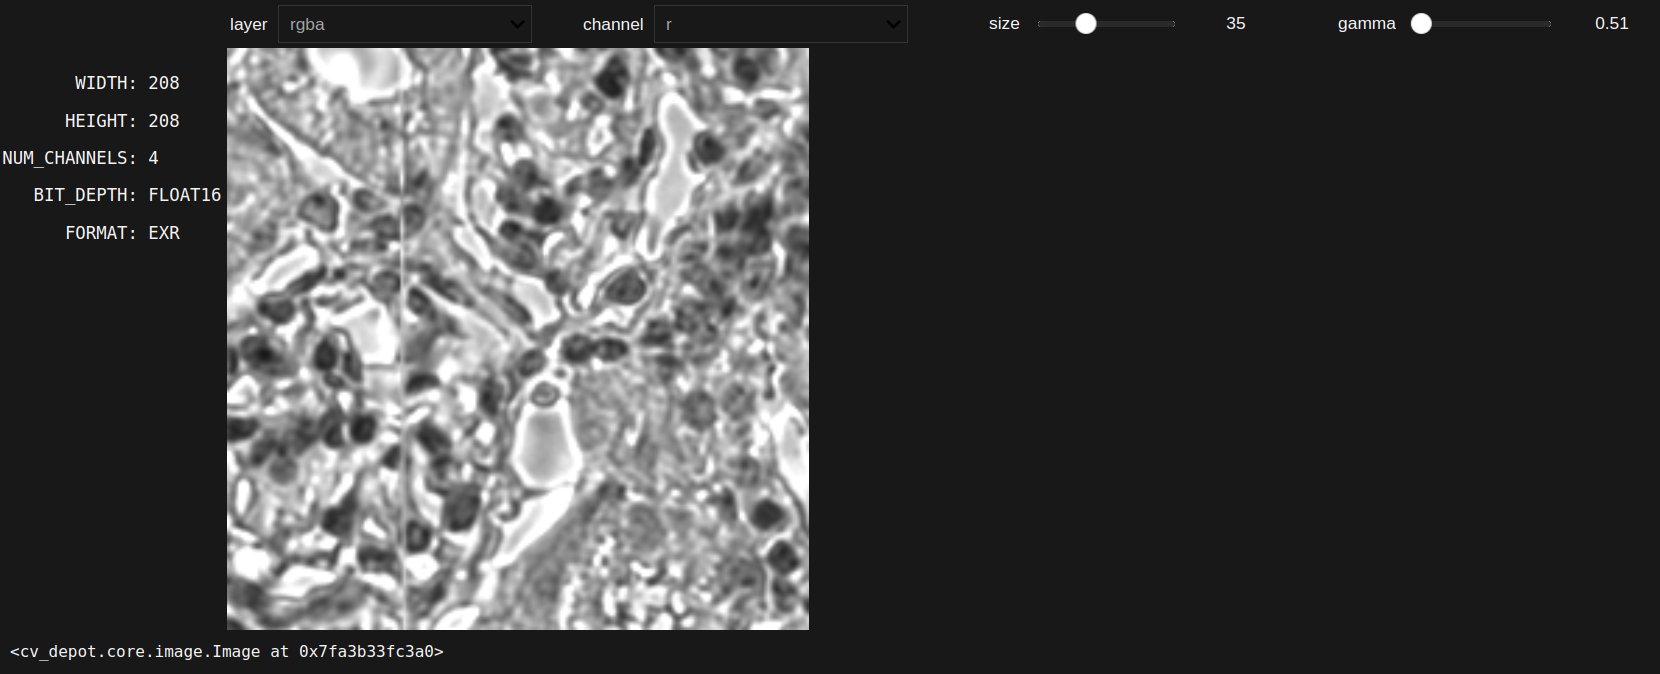

In [38]:
data[42]

<font color='#93B6E6'>The CSV only contains the columns asset_path and filepath_relative. The rest are generated.

In [15]:
data.info

,gb,frame,asset_path,filepath_relative,filepath,loaded
0,0.000127,0,/mnt/storage/projects/unet001/dset002/p-unet00...,data/p-unet001_s-dset002_d-glom_v001_f0000.exr,/mnt/storage/projects/unet001/dset002/p-unet00...,False
1,0.000127,1,/mnt/storage/projects/unet001/dset002/p-unet00...,data/p-unet001_s-dset002_d-glom_v001_f0001.exr,/mnt/storage/projects/unet001/dset002/p-unet00...,False
2,0.000130,2,/mnt/storage/projects/unet001/dset002/p-unet00...,data/p-unet001_s-dset002_d-glom_v001_f0002.exr,/mnt/storage/projects/unet001/dset002/p-unet00...,False
3,0.000124,3,/mnt/storage/projects/unet001/dset002/p-unet00...,data/p-unet001_s-dset002_d-glom_v001_f0003.exr,/mnt/storage/projects/unet001/dset002/p-unet00...,False
4,0.000123,4,/mnt/storage/projects/unet001/dset002/p-unet00...,data/p-unet001_s-dset002_d-glom_v001_f0004.exr,/mnt/storage/projects/unet001/dset002/p-unet00...,False
...,...,...,...,...,...,...
95,0.000125,95,/mnt/storage/projects/unet001/dset002/p-unet00...,data/p-unet001_s-dset002_d-glom_v001_f0095.exr,/mnt/storage/projects/unet001/dset002/p-unet00...,False
96,0.000114,96,/mnt/storage/projects/unet001/dset002/p-unet00...,data/p-unet001_s-dset002_d-glom_v001_f0096.exr,/mnt/storage/projects/unet001/dset002/p-unet00...,False
97,0.000131,97,/mnt/storage/projects/unet001/dset002/p-unet00...,data/p-unet001_s-dset002_d-glom_v001_f0097.exr,/mnt/storage/projects/unet001/dset002/p-unet00...,False
98,0.000123,98,/mnt/storage/projects/unet001/dset002/p-unet00...,data/p-unet001_s-dset002_d-glom_v001_f0098.exr,/mnt/storage/projects/unet001/dset002/p-unet00...,False


<font color='#93B6E6'>Load 50 images from the dataset into memory.

<font color='#93B6E6'>For general workflows, especially Torch dataloaders, it is not necessary to load data. Datasets simply load on request with **\__getitem__**.

In [29]:
data.load(limit=50, shuffle=True)

May not total to 100% - Loading Dataset Files:   0%|          | 0/100 [00:00<?, ?it/s]

<Dataset>
    ASSET_NAME: p-unet001_s-dset002_d-glom_v001
    ASSET_PATH: /mnt/storage/projects/unet001/dset002/p-unet001_s-dset002_d-glom_v001
    STATS:
                    gb  frame  sample
          min     0.00    0.0     NaN
          max     0.00   99.0     NaN
          mean    0.00    NaN     0.0
          std     0.00    NaN     NaN
          loaded  0.02   50.0    50.0
          total   0.01  100.0    36.0

<font color='#93B6E6'>Notice that some rows now have a True value under the loaded column, such as frame 99.

In [30]:
data.info

,gb,frame,asset_path,filepath_relative,filepath,loaded
0,0.000127,0,/mnt/storage/projects/unet001/dset002/p-unet00...,data/p-unet001_s-dset002_d-glom_v001_f0000.exr,/mnt/storage/projects/unet001/dset002/p-unet00...,True
1,0.000127,1,/mnt/storage/projects/unet001/dset002/p-unet00...,data/p-unet001_s-dset002_d-glom_v001_f0001.exr,/mnt/storage/projects/unet001/dset002/p-unet00...,False
2,0.000130,2,/mnt/storage/projects/unet001/dset002/p-unet00...,data/p-unet001_s-dset002_d-glom_v001_f0002.exr,/mnt/storage/projects/unet001/dset002/p-unet00...,True
3,0.000124,3,/mnt/storage/projects/unet001/dset002/p-unet00...,data/p-unet001_s-dset002_d-glom_v001_f0003.exr,/mnt/storage/projects/unet001/dset002/p-unet00...,False
4,0.000123,4,/mnt/storage/projects/unet001/dset002/p-unet00...,data/p-unet001_s-dset002_d-glom_v001_f0004.exr,/mnt/storage/projects/unet001/dset002/p-unet00...,False
...,...,...,...,...,...,...
95,0.000125,95,/mnt/storage/projects/unet001/dset002/p-unet00...,data/p-unet001_s-dset002_d-glom_v001_f0095.exr,/mnt/storage/projects/unet001/dset002/p-unet00...,False
96,0.000114,96,/mnt/storage/projects/unet001/dset002/p-unet00...,data/p-unet001_s-dset002_d-glom_v001_f0096.exr,/mnt/storage/projects/unet001/dset002/p-unet00...,False
97,0.000131,97,/mnt/storage/projects/unet001/dset002/p-unet00...,data/p-unet001_s-dset002_d-glom_v001_f0097.exr,/mnt/storage/projects/unet001/dset002/p-unet00...,False
98,0.000123,98,/mnt/storage/projects/unet001/dset002/p-unet00...,data/p-unet001_s-dset002_d-glom_v001_f0098.exr,/mnt/storage/projects/unet001/dset002/p-unet00...,True


<font color='#93B6E6'>The loaded and gb portions of the stats dataframe have changed as well

In [31]:
data.stats

,gb,frame,sample
min,0.00,0.0,NaN
max,0.00,99.0,NaN
mean,0.00,NaN,0.0
std,0.00,NaN,NaN
loaded,0.02,50.0,50.0
total,0.01,100.0,36.0


In [46]:
print('asset_name:', data.asset_name)
print('asset_path:', data.asset_path)

asset_name: p-unet001_s-dset002_d-glom_v001
asset_path: /mnt/storage/projects/unet001/dset002/p-unet001_s-dset002_d-glom_v001


<font color='#93B6E6'>The first three filepaths of the data. Notice the f000, f0001, f0002 frame fields in the names.

In [33]:
data.filepaths[:3]

['/mnt/storage/projects/unet001/dset002/p-unet001_s-dset002_d-glom_v001/data/p-unet001_s-dset002_d-glom_v001_f0000.exr',
 '/mnt/storage/projects/unet001/dset002/p-unet001_s-dset002_d-glom_v001/data/p-unet001_s-dset002_d-glom_v001_f0001.exr',
 '/mnt/storage/projects/unet001/dset002/p-unet001_s-dset002_d-glom_v001/data/p-unet001_s-dset002_d-glom_v001_f0002.exr']

<font color='#93B6E6'>Calling **load** compiled 50 images into a single numpy array, which is accessed through the **data** member.

In [59]:
data.data.shape

(50, 208, 208, 4)

<font color='#93B6E6'>We handed in a label axis and index when we constructed the Dataset.
<font color='#93B6E6'>A label of [3] here is to the alpha channel (of axis -1).

<font color='#93B6E6'>This information allows us to split **.data** into x and y arrays, using **.xy_split()**

<font color='#93B6E6'>**xy_split** requires **load** to have been called.

In [58]:
x, y = data.xy_split()
print('    labels:', data.labels)
print('label_axis:', data.label_axis)
print('   y.shape:', y.shape)
print('   x.shape:', x.shape)

    labels: [3]
label_axis: -1
   y.shape: (50, 208, 208, 1)
   x.shape: (50, 208, 208, 3)


<font color='#93B6E6'>**unload** simply deletes the **data** member from memory.

In [60]:
data.unload()

<Dataset>
    ASSET_NAME: p-unet001_s-dset002_d-glom_v001
    ASSET_PATH: /mnt/storage/projects/unet001/dset002/p-unet001_s-dset002_d-glom_v001
    STATS:
                    gb  frame  sample
          min     0.00    0.0     NaN
          max     0.00   99.0     NaN
          mean    0.00    NaN     NaN
          std     0.00    NaN     NaN
          loaded  0.00    0.0     NaN
          total   0.01  100.0     NaN

<font color='#93B6E6'>**train_test_split** will split the dataset into train and test dataset according to the labels and label axis.

In [67]:
train, test = data.train_test_split(test_size=0.2, shuffle=True, seed=42)
print('train shape:', train.info.shape)
print(' test shape:', test.info.shape)

train shape: (80, 6)
 test shape: (20, 6)


<font color='#93B6E6'>You can call **.load.xy_split()** on train and test as needed.

In [69]:
train_x, train_y = train.load().xy_split()
print('train_x shape:', train_x.shape)
print('train_y shape:', train_y.shape)

Loading Dataset Files:   0%|          | 0/80 [00:00<?, ?it/s]

train_x shape: (80, 208, 208, 3)
train_y shape: (80, 208, 208, 1)


---
# MultiDatasets

<font color='#93B6E6'>MultiDatasets are a class for combining Datasets of the same length.

In [42]:
fi.MultiDataset

---
# Logging

<font color='#93B6E6'>The following will log a message to the #dev Slack channel given a Slack bot URL.

In [37]:
import time

config = dict(seconds=1, foo='bar')
logger = fi.SlackLogger(
    'CALLED TIME.SLEEP',
    config,
    slack_channel='dev',
    slack_url='https://hooks.slack.com/services/...',
    timezone='America/Detroit',
    level='warn',
)
with logger:
    time.sleep(config['seconds'])


RUN TIME:
```1 second (0:00:01.000797)```
POST TIME:
```2025-03-21T00:03:39.104546-04:00```
CONFIG:
```foo: bar
seconds: 1
```
   
